OPTUNA

https://medium.com/@abhishekjainindore24/optuna-vs-gridsearchcv-vs-randomsearchcv-hyperparameter-tuning-techniques-ea8e2ada28d0

In [1]:
pip install optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ----------------------------

In [47]:
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [48]:
# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [49]:
# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [50]:
df.isnull().values.any()

np.False_

In [51]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [52]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [53]:
# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

Training set shape: (537, 8)
Test set shape: (231, 8)


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [56]:
# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize

In [58]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-02-13 19:19:42,920] A new study created in memory with name: no-name-7b1249ac-71ef-4792-8ee5-d1c2b99c1eb2
[I 2026-02-13 19:19:44,128] Trial 0 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 185, 'max_depth': 19}. Best is trial 0 with value: 0.7635009310986964.
[I 2026-02-13 19:19:45,285] Trial 1 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 184, 'max_depth': 15}. Best is trial 1 with value: 0.7653631284916201.
[I 2026-02-13 19:19:45,810] Trial 2 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 82, 'max_depth': 12}. Best is trial 2 with value: 0.7690875232774674.
[I 2026-02-13 19:19:46,711] Trial 3 finished with value: 0.7597765363128491 and parameters: {'n_estimators': 137, 'max_depth': 16}. Best is trial 2 with value: 0.7690875232774674.
[I 2026-02-13 19:19:47,621] Trial 4 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 137, 'max_depth': 14}. Best is trial 2 with value: 0.76908

In [60]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7988826815642458
Best hyperparameters: {'n_estimators': 51, 'max_depth': 8}


In [61]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

Test Accuracy with best hyperparameters: 0.74


Samplers in Optuna

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [63]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-02-13 19:20:37,007] A new study created in memory with name: no-name-c18a875b-3294-47cf-bdbb-c9006589a374
[I 2026-02-13 19:20:38,189] Trial 0 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 181, 'max_depth': 20}. Best is trial 0 with value: 0.7616387337057727.
[I 2026-02-13 19:20:39,298] Trial 1 finished with value: 0.7597765363128491 and parameters: {'n_estimators': 182, 'max_depth': 17}. Best is trial 0 with value: 0.7616387337057727.
[I 2026-02-13 19:20:39,684] Trial 2 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 62, 'max_depth': 12}. Best is trial 2 with value: 0.7635009310986964.
[I 2026-02-13 19:20:40,434] Trial 3 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 120, 'max_depth': 13}. Best is trial 3 with value: 0.7728119180633147.
[I 2026-02-13 19:20:41,629] Trial 4 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 199, 'max_depth': 20}. Best is trial 3 with value: 0.77281

In [64]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7839851024208566
Best hyperparameters: {'n_estimators': 117, 'max_depth': 9}


In [65]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


In [66]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [67]:
# Create a study and optimize it using GridSampler
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2026-02-13 19:21:19,598] A new study created in memory with name: no-name-4711206d-7045-4c6b-8671-cd2608fe4d4f
[I 2026-02-13 19:21:20,214] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-02-13 19:21:21,242] Trial 1 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 1 with value: 0.7709497206703911.
[I 2026-02-13 19:21:21,592] Trial 2 finished with value: 0.7802607076350094 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7802607076350094.
[I 2026-02-13 19:21:22,265] Trial 3 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7802607076350094.
[I 2026-02-13 19:21:22,951] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.780260

In [68]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7802607076350094
Best hyperparameters: {'n_estimators': 50, 'max_depth': 15}


In [69]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.75


Optuna Visualization


In [70]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

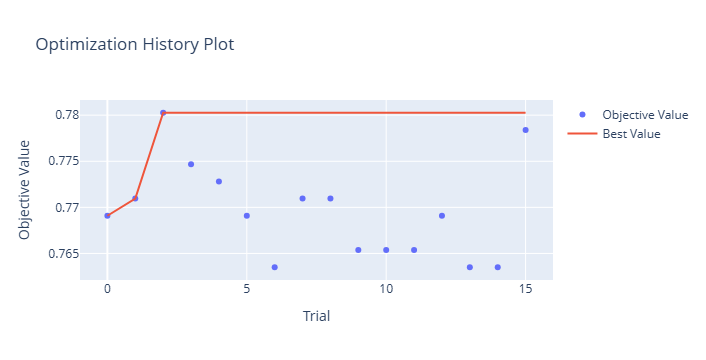

In [71]:
# 1. Optimization History
plot_optimization_history(study).show()

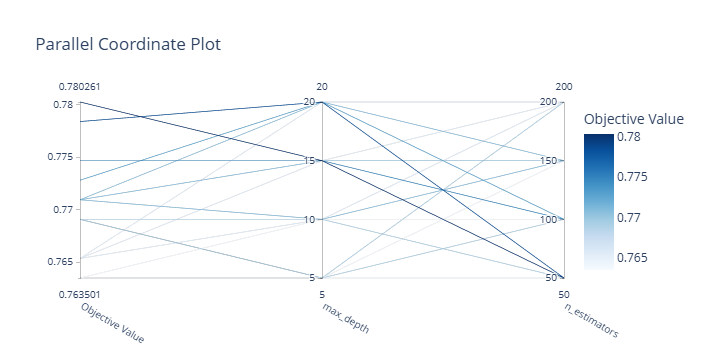

In [72]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

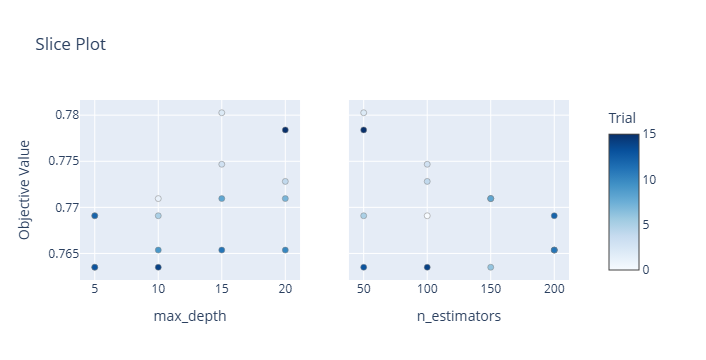

In [73]:
# 3. Slice Plot
plot_slice(study).show()

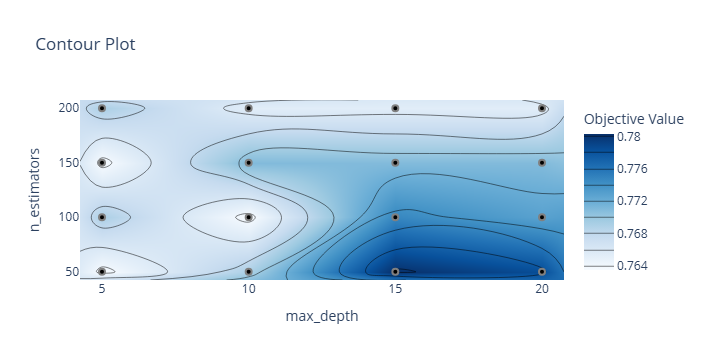

In [74]:
# 4. Contour Plot
plot_contour(study).show()

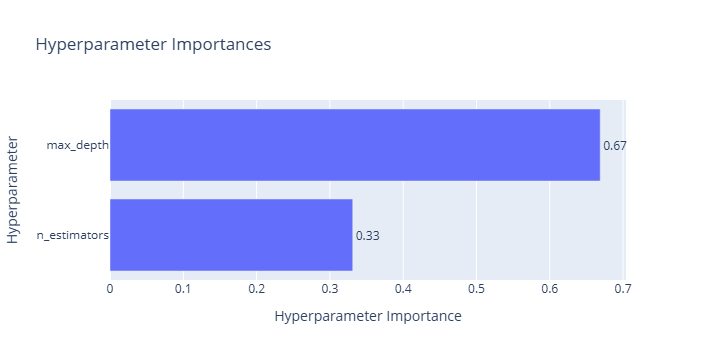

In [75]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

Optimizing Multiple ML models

In [76]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [77]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [78]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-02-13 19:22:22,542] A new study created in memory with name: no-name-3de1e8f0-eceb-4fda-bc99-49d8b5598390
[I 2026-02-13 19:22:22,581] Trial 0 finished with value: 0.7690875232774674 and parameters: {'classifier': 'SVM', 'C': 1.9223227747383955, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-02-13 19:22:23,951] Trial 1 finished with value: 0.7486033519553073 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 115, 'learning_rate': 0.07592862399247995, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-02-13 19:22:28,209] Trial 2 finished with value: 0.750465549348231 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 279, 'learning_rate': 0.14715631570975268, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-02-13 19:22:29,136] Trial 3 finished with value: 0.7765363

In [79]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'RandomForest', 'n_estimators': 263, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 1, 'bootstrap': False}
Best trial accuracy: 0.7914338919925511


In [80]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.769088,2026-02-13 19:22:22.543654,2026-02-13 19:22:22.581522,0 days 00:00:00.037868,1.922323,NaN,SVM,auto,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE
1,1,0.748603,2026-02-13 19:22:22.582833,2026-02-13 19:22:23.951401,0 days 00:00:01.368568,NaN,NaN,GradientBoosting,NaN,NaN,0.075929,20.0,10.0,8.0,115.0,COMPLETE
2,2,0.750466,2026-02-13 19:22:23.953404,2026-02-13 19:22:28.209780,0 days 00:00:04.256376,NaN,NaN,GradientBoosting,NaN,NaN,0.147156,20.0,7.0,6.0,279.0,COMPLETE
3,3,0.776536,2026-02-13 19:22:28.211443,2026-02-13 19:22:29.136385,0 days 00:00:00.924942,NaN,False,RandomForest,NaN,NaN,NaN,16.0,3.0,2.0,147.0,COMPLETE
4,4,0.739292,2026-02-13 19:22:29.137519,2026-02-13 19:22:29.168897,0 days 00:00:00.031378,0.892678,NaN,SVM,auto,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.783985,2026-02-13 19:24:33.587774,2026-02-13 19:24:34.982914,0 days 00:00:01.395140,NaN,False,RandomForest,NaN,NaN,NaN,17.0,2.0,9.0,264.0,COMPLETE
96,96,0.731844,2026-02-13 19:24:34.984480,2026-02-13 19:24:41.195959,0 days 00:00:06.211479,NaN,NaN,GradientBoosting,NaN,NaN,0.071506,18.0,1.0,9.0,257.0,COMPLETE
97,97,0.754190,2026-02-13 19:24:41.197480,2026-02-13 19:24:41.257804,0 days 00:00:00.060324,9.704729,NaN,SVM,auto,poly,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.791434,2026-02-13 19:24:41.259800,2026-02-13 19:24:42.878306,0 days 00:00:01.618506,NaN,False,RandomForest,NaN,NaN,NaN,16.0,1.0,9.0,281.0,COMPLETE


In [81]:
study.trials_dataframe()['params_classifier'].value_counts()

params_classifier
RandomForest        78
GradientBoosting    12
SVM                 10
Name: count, dtype: int64

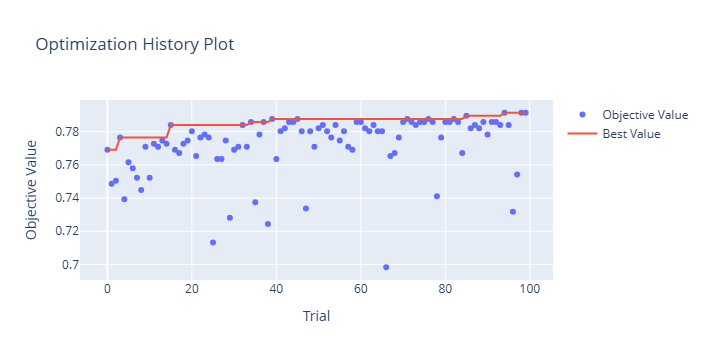

In [82]:
# 1. Optimization History
plot_optimization_history(study).show()

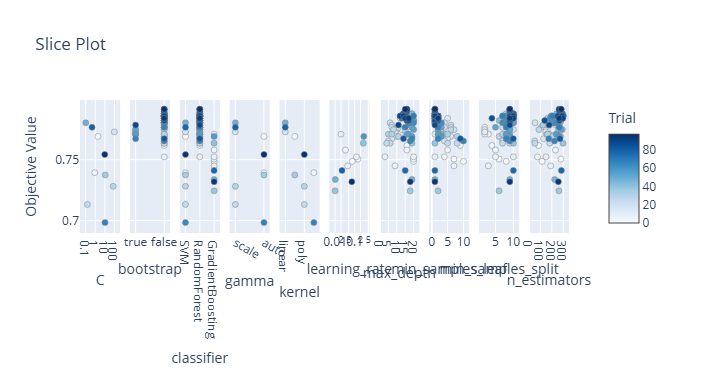

In [83]:
# 3. Slice Plot
plot_slice(study).show()

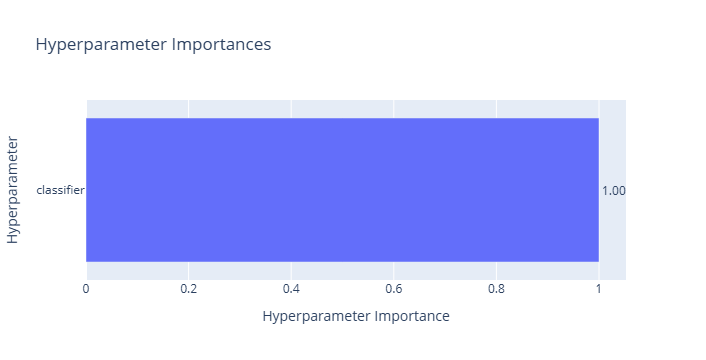

In [84]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()


In [85]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Iris dataset
X, y = load_iris(return_X_y=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function for XGBoost
def objective(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=50)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")


[I 2026-02-13 19:25:34,189] A new study created in memory with name: no-name-194e97ad-90a4-48a8-8199-1e01a645db4c


[0]	train-mlogloss:0.76942	eval-mlogloss:0.77185
[1]	train-mlogloss:0.56205	eval-mlogloss:0.54661
[2]	train-mlogloss:0.42883	eval-mlogloss:0.40559
[3]	train-mlogloss:0.33220	eval-mlogloss:0.30218
[4]	train-mlogloss:0.26802	eval-mlogloss:0.23365
[5]	train-mlogloss:0.22661	eval-mlogloss:0.18736
[6]	train-mlogloss:0.19949	eval-mlogloss:0.15376
[7]	train-mlogloss:0.19242	eval-mlogloss:0.14484
[8]	train-mlogloss:0.17415	eval-mlogloss:0.11992
[9]	train-mlogloss:0.17145	eval-mlogloss:0.11964
[10]	train-mlogloss:0.16614	eval-mlogloss:0.11476
[11]	train-mlogloss:0.16185	eval-mlogloss:0.10893
[12]	train-mlogloss:0.16105	eval-mlogloss:0.10771
[13]	train-mlogloss:0.15969	eval-mlogloss:0.10684
[14]	train-mlogloss:0.15974	eval-mlogloss:0.10605
[15]	train-mlogloss:0.15954	eval-mlogloss:0.10596
[16]	train-mlogloss:0.15815	eval-mlogloss:0.10480
[17]	train-mlogloss:0.15747	eval-mlogloss:0.10447
[18]	train-mlogloss:0.15755	eval-mlogloss:0.10366
[19]	train-mlogloss:0.15643	eval-mlogloss:0.10308
[20]	train

[I 2026-02-13 19:25:34,757] Trial 0 finished with value: 1.0 and parameters: {'lambda': 1.6170697258478002e-07, 'alpha': 4.439223412414777e-06, 'eta': 0.2960763129643819, 'gamma': 2.9254424409293915e-08, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.6318094640057196, 'colsample_bytree': 0.8790908700329932}. Best is trial 0 with value: 1.0.


[0]	train-mlogloss:0.90337	eval-mlogloss:0.89279
[1]	train-mlogloss:0.80554	eval-mlogloss:0.79906
[2]	train-mlogloss:0.68777	eval-mlogloss:0.66920
[3]	train-mlogloss:0.58110	eval-mlogloss:0.55704
[4]	train-mlogloss:0.50238	eval-mlogloss:0.47276
[5]	train-mlogloss:0.43263	eval-mlogloss:0.39775
[6]	train-mlogloss:0.38071	eval-mlogloss:0.34093
[7]	train-mlogloss:0.33428	eval-mlogloss:0.29058
[8]	train-mlogloss:0.29468	eval-mlogloss:0.24874
[9]	train-mlogloss:0.26319	eval-mlogloss:0.21461
[10]	train-mlogloss:0.23776	eval-mlogloss:0.18841
[11]	train-mlogloss:0.21072	eval-mlogloss:0.16612
[12]	train-mlogloss:0.19370	eval-mlogloss:0.14912
[13]	train-mlogloss:0.17738	eval-mlogloss:0.13046
[14]	train-mlogloss:0.16369	eval-mlogloss:0.11497
[15]	train-mlogloss:0.15514	eval-mlogloss:0.10572
[16]	train-mlogloss:0.14549	eval-mlogloss:0.09591
[17]	train-mlogloss:0.13789	eval-mlogloss:0.08806
[18]	train-mlogloss:0.13103	eval-mlogloss:0.08202
[19]	train-mlogloss:0.12455	eval-mlogloss:0.07780
[20]	train

[I 2026-02-13 19:25:35,232] Trial 1 finished with value: 1.0 and parameters: {'lambda': 5.433674025282265e-06, 'alpha': 1.0673556847847676e-05, 'eta': 0.1578639902533218, 'gamma': 0.6517368927108461, 'max_depth': 5, 'min_child_weight': 2, 'subsample': 0.731106417373343, 'colsample_bytree': 0.7484889732919837}. Best is trial 0 with value: 1.0.


...

[0]	train-mlogloss:1.08508	eval-mlogloss:1.08526
[1]	train-mlogloss:1.07123	eval-mlogloss:1.07084
[2]	train-mlogloss:1.05699	eval-mlogloss:1.05648
[3]	train-mlogloss:1.04318	eval-mlogloss:1.04205
[4]	train-mlogloss:1.02986	eval-mlogloss:1.02876
[5]	train-mlogloss:1.01655	eval-mlogloss:1.01466
[6]	train-mlogloss:1.00406	eval-mlogloss:1.00164
[7]	train-mlogloss:0.99154	eval-mlogloss:0.98811
[8]	train-mlogloss:0.97972	eval-mlogloss:0.97529
[9]	train-mlogloss:0.96691	eval-mlogloss:0.96213
[10]	train-mlogloss:0.95505	eval-mlogloss:0.94965
[11]	train-mlogloss:0.94338	eval-mlogloss:0.93710
[12]	train-mlogloss:0.93196	eval-mlogloss:0.92573
[13]	train-mlogloss:0.92029	eval-mlogloss:0.91350
[14]	train-mlogloss:0.90927	eval-mlogloss:0.90188
[15]	train-mlogloss:0.89821	eval-mlogloss:0.89028
[16]	train-mlogloss:0.88710	eval-mlogloss:0.87860
[17]	train-mlogloss:0.87672	eval-mlogloss:0.86815
[18]	train-mlogloss:0.86621	eval-mlogloss:0.85743
[19]	train-mlogloss:0.85579	eval-mlogloss:0.84646
[20]	train

[I 2026-02-13 19:25:39,136] Trial 48 pruned. Trial was pruned at iteration 32.


[0]	train-mlogloss:1.04441	eval-mlogloss:1.04510
[1]	train-mlogloss:0.99191	eval-mlogloss:0.99038
[2]	train-mlogloss:0.94074	eval-mlogloss:0.93867
[3]	train-mlogloss:0.89356	eval-mlogloss:0.88882
[4]	train-mlogloss:0.85023	eval-mlogloss:0.84470
[5]	train-mlogloss:0.80930	eval-mlogloss:0.80121
[6]	train-mlogloss:0.77241	eval-mlogloss:0.76258
[7]	train-mlogloss:0.73773	eval-mlogloss:0.72546


[I 2026-02-13 19:25:39,193] Trial 49 pruned. Trial was pruned at iteration 8.


Best trial: {'lambda': 1.6170697258478002e-07, 'alpha': 4.439223412414777e-06, 'eta': 0.2960763129643819, 'gamma': 2.9254424409293915e-08, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.6318094640057196, 'colsample_bytree': 0.8790908700329932}
Best accuracy: 1.0


In [86]:
 pip install optuna-integration[xgboost]

Note: you may need to restart the kernel to use updated packages.


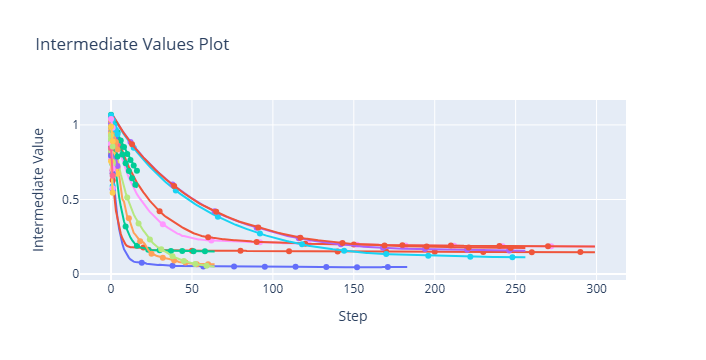

In [43]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()